
# Lab 4: FDM-diffusion

### Estudiante: Estiven Castrillon, 1040570656

 **Exercise** : Heat diffusion in a plate using FDM

Let's consider a rectangular heat-conducting plate with sides of lengths $a=20$ mm and $b=10$ mm. It has borders a temperature as is shown in figure.  The flat faces are isolated, so they can't lose head to the surroundings. The material is aluminum with thermal diffusivity $D\approx 84\, mm^2/s$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/plato_coductor2.jpg" alt="Texto alternativo" width="400" height="400">

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import time as tm

1. Use **FDM** to solve the *static solution* for this system for $f(x)=100\,\sin(3\pi x/a)$ C.
2. Use **FDM** to found the temperature, i.e., solve the diffusion equation for some times.

dt = 2.976190476190477e-05


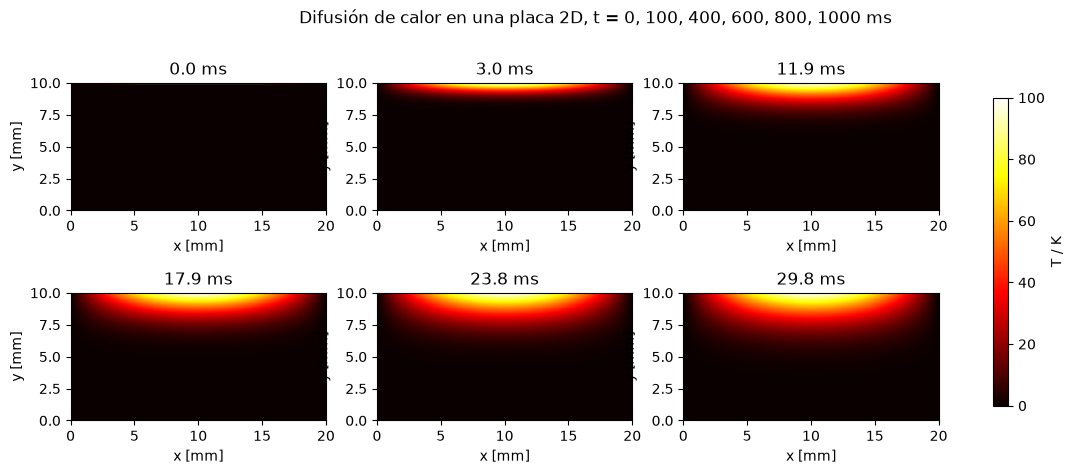

In [24]:
w, h = 20, 10 # tamaño de la placa [mm]
dx = dy = 0.1 # espaciamiento espacial [mm]
D = 84 # difusividad térmica [mm^2/s]
Tcool = 0 # temperatura de las paredes [K]

# Temperatura del techo [K]
Thot = 100
def f(x):
    return Thot * np.sin(np.pi * x / w) + Tcool

# Grid
nx = int(w/dx) + 1
ny = int(h/dy) + 1

dx2 = dx**2
dy2 = dy**2

# Paso temporal
dt = dx2 * dy2 / (2 * D * (dx2 + dy2))

print("dt =", dt)

# Condiciones iniciales
u0 = Tcool * np.ones((nx, ny)) # Todo en cero
u = u0.copy()

# Definición de un solo paso temporal
def do_timestep(u0, u):

    # Ecuación de difusión para los puntos interiores
    u[1:-1, 1:-1] = u0[1:-1, 1:-1] + D*dt*(u0[2:, 1:-1] + u0[:-2, 1:-1] + u0[1:-1, 2:] + u0[1:-1, :-2]- 4*u0[1:-1, 1:-1])/dx2

    # Condiciones de frontera
    u[:, 0] = Tcool # Pared inferior: y = 0
    u[0, :] = Tcool # Pared izquierda: x = 0
    u[-1, :] = Tcool # Pared derecha: x = w

    # Techo: y = h
    x = np.arange(nx) * dx 
    u[:, -1] = f(x)

    # El nuevo estado pasa a ser el estado anterior
    u0 = u.copy()

    return u0, u

# Simulación completa y guardado de snapshots
nsteps = 10001
snapshots = []
times = []

u0 = Tcool * np.ones((nx, ny))
u = u0.copy()

for step in range(nsteps):
    u0, u = do_timestep(u0, u)
    if step in [0, 100, 400, 600, 800, 1000]:
        snapshots.append(u.copy())
        times.append(step * dt * 1000)  # en ms

# Graficar en grid para ver el cambio con distintos tiempos
fig, axes = plt.subplots(2, 3, figsize=(14, 5))
fig.suptitle("Difusión de calor en una placa 2D, t = 0, 100, 400, 600, 800, 1000 ms")
axes = axes.ravel()

for i, ax in enumerate(axes):
    im = ax.imshow(
        snapshots[i].T,
        cmap="hot",
        origin="lower",
        extent=[0, w, 0, h],
        vmin=Tcool,
        vmax=Thot + Tcool
    )
    ax.set_title(f"{times[i]:.1f} ms")
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]")

fig.colorbar(im, ax=axes.tolist(), shrink=0.8, label="T / K")
plt.show()


3. Compare the *static solution* with the analytical one.


In [25]:
tol = 1e-8

while True:
    u_old = u.copy()
    u0, u = do_timestep(u0, u)

    error = np.max(np.abs(u - u_old))

    if error < tol:
        break

print("Estado estacionario alcanzado en el paso temporal:", step, "con error máximo:", error)

Estado estacionario alcanzado en el paso temporal: 10000 con error máximo: 9.998274208555813e-09


Solución hecha a mano, no considero que sea necesaria poner el desarrollo aquí, no estamos en fisica matemática 1 y es un ejercicio que se repitió varias veces en ese curso. La solución analítica es: $T(x,y)=100\sin\left(\frac{\pi x}{20}\right)\frac{\sinh\left(\frac{\pi y}{20}\right)}{\sinh\left(\frac{\pi}{2}\right)}$


In [26]:
x = np.linspace(0, w, nx)
y = np.linspace(0, h, ny)

X, Y = np.meshgrid(x, y, indexing="ij")

T_analytical = (
    Thot
    * np.sin(np.pi * X / w)
    * np.sinh(np.pi * Y / w)
    / np.sinh(np.pi * h / w)
)

error = np.abs(u - T_analytical)

print("Error máximo =", np.max(error), "K")

Error máximo = 0.0003906924010195212 K


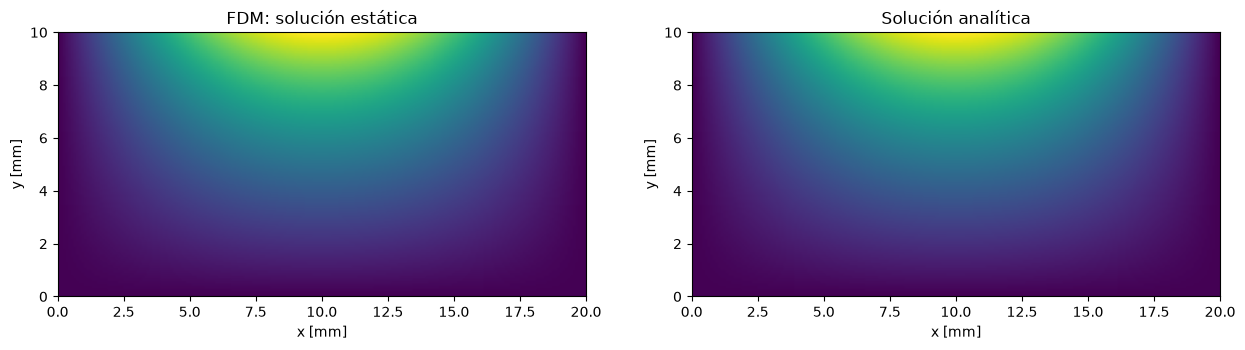

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].imshow(u.T, origin="lower", extent=[0,w,0,h])
axes[0].set_title("FDM: solución estática")

axes[1].imshow(T_analytical.T, origin="lower", extent=[0,w,0,h])
axes[1].set_title("Solución analítica")

for ax in axes:
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]")

plt.show()

La solución estática obtenida mediante el método de diferencias finitas presenta una excelente concordancia con la solución analítica.El error máximo es de $3.9\times10^{-4}\,\mathrm{K}$, correspondiente a un error relativo aproximado de $0.00039\%$.

4. Do a gif for the temperature in time (bonus!)

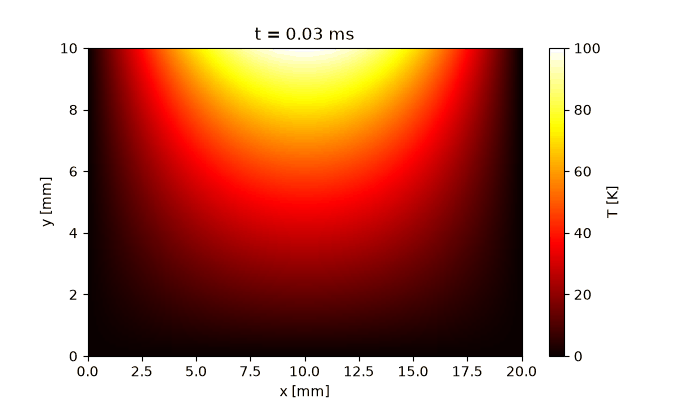

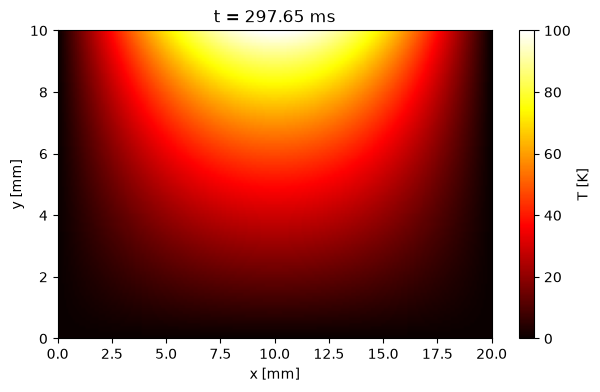

In [28]:
from matplotlib.animation import FuncAnimation, PillowWriter

# Guardar algunos estados para el GIF
snapshots = []
times = []

for step in range(nsteps):

    u0, u = do_timestep(u0, u)

    # Guardamos cada 20 pasos
    if step % 50 == 0:
        snapshots.append(u.copy())
        times.append((step + 1) * dt)

# Crear figura
fig, ax = plt.subplots(figsize=(7, 4))

im = ax.imshow(
    snapshots[0].T,
    cmap="hot",
    origin="lower",
    extent=[0, w, 0, h],
    vmin=Tcool,
    vmax=Thot,
    aspect="auto"
)

ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("T [K]")

title = ax.set_title(
    f"t = {times[0]*1000:.2f} ms"
)

# Actualizar cada cuadro
def update(frame):

    im.set_data(snapshots[frame].T)

    title.set_text(
        f"t = {times[frame]*1000:.2f} ms"
    )

    return im, title

# Crear animación
ani = FuncAnimation(
    fig,
    update,
    frames=len(snapshots),
    interval=50,
    blit=True
)

# Guardar el GIF
ani.save("difusion_temperatura.gif", writer=PillowWriter(fps=20))

# Mostrarlo en el notebook
from IPython.display import Image
Image(filename="difusion_temperatura.gif")